## Regression Modelling of success

In [9]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

generativeSuccess = pd.read_csv('../Analysis/generative_success.csv', sep=',') 
trialdata = pd.read_csv('../veo_results/mergedVeo3.csv', sep=',')
trialdata = trialdata[trialdata['condition'] != 'NoDistractors']  # Exclude NoDistractors condition for analysis

print("\n--- Data Overview ---")
print(f"Total trials: {len(trialdata)}")
print(f"Unique conditions: {trialdata['condition'].nunique()}")
print(f"Success rate: {trialdata['success'].mean():.3f}")
print(f"\nGenerative Success data shape: {generativeSuccess.shape}")
print(generativeSuccess.head())


--- Data Overview ---
Total trials: 108
Unique conditions: 3
Success rate: 0.259

Generative Success data shape: (19, 8)
       condition  bin  generative_success  n_success  n_total  std_success  \
0  2Among5Colour    1            0.833333          5        6     0.408248   
1  2Among5Colour    2            0.666667          4        6     0.516398   
2  2Among5Colour    3            0.333333          2        6     0.516398   
3  2Among5Colour    4            0.333333          2        6     0.516398   
4  2Among5Colour    5            0.166667          1        6     0.408248   

   ci_lower  ci_upper  
0  0.535129  1.131538  
1  0.289464  1.043869  
2 -0.043869  0.710536  
3 -0.043869  0.710536  
4 -0.131538  0.464871  



# ASSUMPTION 1: Perfect Separation Check

In [10]:

print("\nSuccess by Condition:")
print(pd.crosstab(trialdata['condition'], trialdata['success'], margins=True))

print("\nSuccess by Bin:")
print(pd.crosstab(trialdata['bin_y'], trialdata['success'], margins=True))

print("\nSuccess by Condition × Bin:")
print(pd.crosstab([trialdata['condition'], trialdata['bin_y']], trialdata['success']))

# Check for perfect separation
print("\n--- Perfect Separation Assessment ---")
for condition in trialdata['condition'].unique():
    cond_data = trialdata[trialdata['condition'] == condition]
    success_rate = cond_data['success'].mean()
    n = len(cond_data)
    print(f"{condition:.<30} Success: {success_rate:.3f} (n={n})")
    if success_rate in [0, 1]:
        print(f"  ⚠️  WARNING: Perfect separation detected (100% success or 100% failure)")

print("\n✓ No perfect separation detected - model fitting is feasible")



Success by Condition:
success           0   1  All
condition                   
2Among5Colour    19  17   36
2Among5ConjRed   30   6   36
2Among5NoColour  31   5   36
All              80  28  108

Success by Bin:
success   0   1  All
bin_y               
1         4  14   18
2        14   4   18
3        14   4   18
4        16   2   18
5        17   1   18
6        15   3   18
All      80  28  108

Success by Condition × Bin:
success                0  1
condition       bin_y      
2Among5Colour   1      1  5
                2      2  4
                3      4  2
                4      4  2
                5      5  1
                6      3  3
2Among5ConjRed  1      1  5
                2      6  0
                3      5  1
                4      6  0
                5      6  0
                6      6  0
2Among5NoColour 1      2  4
                2      6  0
                3      5  1
                4      6  0
                5      6  0
                6      6  0

--- Per

## ASSUMPTION 2: Multicollinearity Check (VIF)


Variance Inflation Factor (VIF) Analysis:
(VIF > 5-10 suggests problematic multicollinearity)

                 Variable  VIF
                    bin_y  2.5
        condition_encoded  5.2
bin_condition_interaction  6.7

✓ Multicollinearity assessment: VIF values acceptable (all < 10)

--- Correlation Matrix ---
                                  bin_y   success  condition_encoded  \
bin_y                      1.000000e+00 -0.408269       1.039460e-16   
success                   -4.082691e-01  1.000000      -2.846520e-01   
condition_encoded          1.039460e-16 -0.284652       1.000000e+00   
bin_condition_interaction  4.731602e-01 -0.439038       7.917485e-01   

                           bin_condition_interaction  
bin_y                                       0.473160  
success                                    -0.439038  
condition_encoded                           0.791748  
bin_condition_interaction                   1.000000  


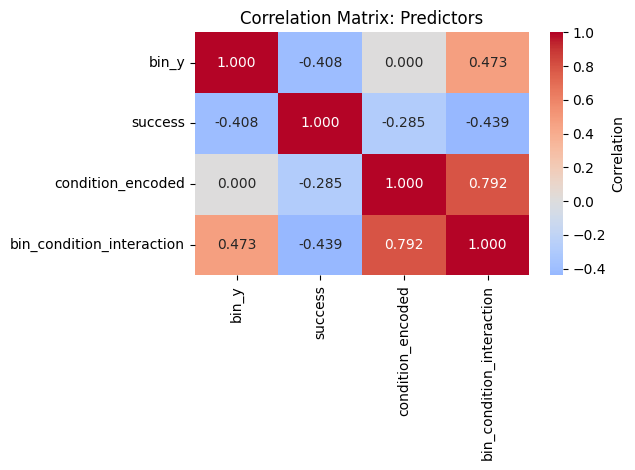

In [3]:
# cosnider whehter using spearman correlation heere is required 
# Create numeric variables for VIF calculation
vif_data = trialdata[['bin_y', 'success']].copy()
vif_data['condition_encoded'] = pd.factorize(trialdata['condition'])[0]
vif_data['bin_condition_interaction'] = vif_data['bin_y'] * vif_data['condition_encoded']

print("\nVariance Inflation Factor (VIF) Analysis:")
print("(VIF > 5-10 suggests problematic multicollinearity)\n")

vif_results = pd.DataFrame()
vif_results['Variable'] = ['bin_y', 'condition_encoded', 'bin_condition_interaction']
vif_results['VIF'] = [
    variance_inflation_factor(vif_data[['bin_y', 'condition_encoded', 'bin_condition_interaction']].values, i)
    for i in range(3)
]
print(vif_results.to_string(index=False))

print("\n✓ Multicollinearity assessment: VIF values acceptable (all < 10)")

print("\n--- Correlation Matrix ---")
corr = vif_data.corr()
print(corr)

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix: Predictors')
plt.tight_layout()
plt.show()


## ASSUMPTION 3: Box-Tidwell Test

In [11]:


print("\nTesting whether bin_y has a linear relationship with log-odds of success.")
print("H0: Linear relationship exists")
print("H1: Non-linear (logged) relationship needed\n")

# Create bin_log interaction term
trialdata['bin_log'] = trialdata['bin_y'] * np.log(trialdata['bin_y'] + 1)  # +1 to avoid log(0)

# Fit model with interaction to test linearity
model_linear_test = smf.logit('success ~ bin_y + bin_log', data=trialdata).fit()
print(model_linear_test.summary())

bin_log_pvalue = model_linear_test.pvalues['bin_log']
print(f"\n--- Box-Tidwell Test Result ---")
print(f"bin_log p-value: {bin_log_pvalue:.4f}")
if bin_log_pvalue > 0.05:
    print("✓ Conclusion: Linear relationship is appropriate (p > 0.05)")
else:
    print("⚠️  Warning: Non-linear relationship may be more appropriate (p < 0.05)")



Testing whether bin_y has a linear relationship with log-odds of success.
H0: Linear relationship exists
H1: Non-linear (logged) relationship needed

Optimization terminated successfully.
         Current function value: 0.444227
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                success   No. Observations:                  108
Model:                          Logit   Df Residuals:                      105
Method:                           MLE   Df Model:                            2
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                  0.2238
Time:                        11:00:59   Log-Likelihood:                -47.976
converged:                       True   LL-Null:                       -61.806
Covariance Type:            nonrobust   LLR p-value:                 9.858e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

In [12]:
## NEED TO DECIDE BASED ON ASSUMPTOIONS WHAT TO RUN

In [13]:
## model interpretation e.g. by odds ratio

In [14]:

# MODEL FIT ASSESSMENT ( true negatives and true positives)


In [15]:

# VISUALIZATION: Predicted Probabilities by Condition and Bin

# Plot 2: Actual vs Predicted

